In [ ]:
import pandas as pd

df = pd.read_csv('job_budget_data.csv', on_bad_lines='warn')

df.head()

C:\Users\didkn\AppData\Local\Temp\ipykernel_20556\4159550686.py:3: ParserWarning: Skipping line 5: expected 16 fields, saw 17
Skipping line 7: expected 16 fields, saw 17
Skipping line 10: expected 16 fields, saw 17
Skipping line 12: expected 16 fields, saw 17

  df = pd.read_csv('job_budget_data.csv',


,Date Applied,Company,Role,Status,Salary Range,Applied Via,Notes,Follow Up Date,Interview Date,Offer Amount,Rent,Utilities,Groceries,Transport,Entertainment,Savings
0,2024-01-15,Tech Corp,Data Analyst,Rejected,70k-80k,LinkedIn,NaN,NaN,NaN,NaN,1500,120,400,100,200,500
1,2024-01-20,NaN,Junior Data Analyst,Applied,65k-75k,Indeed,spelled company name wrong,NaN,NaN,NaN,1400,110,380,90,180,450
2,2024-01-25,DataSolve,Data Analyst,Interview,75k-85k,Company Website,2nd round next week,2024-02-01,2024-02-05,NaN,1600,130,420,120,220,600
3,2024-02-05,Tech Corp,Data Analyst,No Response,70k-80k,LinkedIn,ghosted,NaN,NaN,NaN,1450,115,390,95,190,480
4,2024-02-15,Insight Solutions,Data Analyst,Offer,80k-90k,Recruiter,negotiating salary,2024-02-20,2024-02-12,85000.0,1550,125,410,110,210,550


# You can't analyze what you can't read.
 - I track job apps and monthly spending in a CSV. But look at this:

🔴 Blank rows
🔴 Missing company names
🔴 Empty salary fields
🔴 Inconsistent data

In [29]:
# Where is the data missing

missing = df.isnull().sum()
print(missing[missing > 0])

Notes             1
Follow Up Date    3
Interview Date    1
Offer Amount      7
dtype: int64


Results:

- Company: 2 missing
- Role: 3 missing
- Salary Range: 4 missing
- Interview Date: 8 missing
- Rent: 1 missing (a whole row of zeros!)

- tip: Use df.info() and
 df.isnull().sum() before cleaning.
  Know your enemy

In [30]:
# Drop completely empty rows
df = df.dropna(how='all')

# Drop rows missing CRITICAL data
df = df.dropna(subset=['Company', 
'Role', 'Status'])

print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 8


Rule: If you can't fill it, kill it. Bad data > no data? No. Bad data = bad insights.

In [31]:
# Forward fill missing interview dates
df['Interview Date'] = df['Interview Date'].ffill()

# Fill missing salary ranges with median
df['Salary_Range_Low'] = df['Salary Range'].str.extract(r'(\d+)k').astype(float)
median_salary = df['Salary_Range_Low'].median()
df['Salary_Range_Low'] = df['Salary_Range_Low'].fillna(median_salary)

Strategy: Delete what's hopeless. Fill what has context. Always document your assumptions

In [32]:
# Extract numeric salary
df['Salary_Offer'] = df['Offer Amount'].fillna(0)

# Calculate rent-to-income ratio (30% rule)
df['Rent_to_Income'] = (df['Rent'] * 12) / df['Salary_Offer']

# Flag unaffordable rent
df['Rent_Affordable'] = df['Rent_to_Income'] <= 0.3

# Save clean version
df.to_csv('cleaned_data.csv', index=False)

Now I can instantly see which job offers let me live comfortably.

Visualization + Saving Clean Data

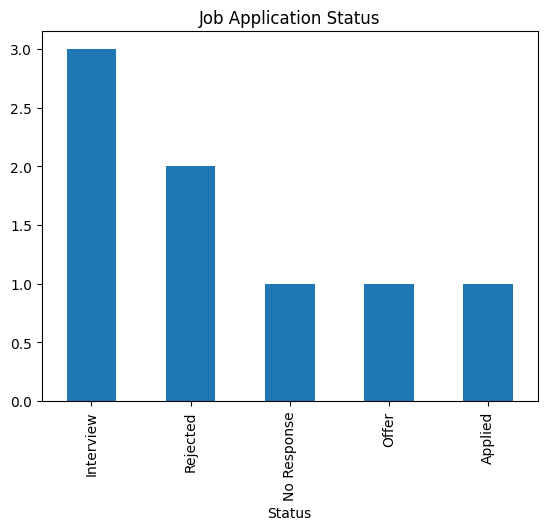

In [33]:
import matplotlib.pyplot as plt

# Application status breakdown
df['Status'].value_counts().plot(kind='bar')
plt.title('Job Application Status')
plt.show()

# Save cleaned data
df.to_csv('job_budget_cleaned.csv', index=False)